# Foundations of Linear Algebra: Vectors, Matrices, and Similarity Metrics
## Funções de Ativação em Redes Neurais

### 1. Contextualização histórica e motivação

Esta seção introduz o contexto histórico das funções de ativação, desde os primeiros perceptrons até as arquiteturas modernas, o que é fundamental para compreender a evolução do aprendizado de máquina.

A modelagem de problemas não lineares, como o clássico problema da porta lógica XOR, motivou o desenvolvimento de funções de ativação complexas. Historicamente, a primeira tentativa de reproduzir o neurônio humano ocorreu matematicamente em 1943 por Warren McCulloch e Walter Pitts, sendo implementada em máquina por Frank Rosenblatt em 1957 sob o nome de Perceptron. O Perceptron utilizava uma função de ativação linear ou função degrau (step function) que retornava 1 se o valor excedesse um limiar e 0 caso contrário. Em 1969, Minsky e Papert provaram que um perceptron de camada única com essa natureza linear era incapaz de resolver o problema do XOR, evidenciando a insuficiência das soluções da época e a necessidade de não linearidades.

A evolução exigiu o desenvolvimento do *Multilayer Perceptron* (MLP) com funções de ativação não lineares contínuas e diferenciáveis (como Sigmoid e Tanh). O treinamento dessas redes só se tornou viável e escalável em 1986, quando Geoffrey Hinton, David Rumelhart e Ronald Williams formalizaram o algoritmo de *Backpropagation*. Atualmente, no estado da arte de 2024-2025, o uso de funções de ativação evoluiu para variantes computacionalmente otimizadas que mitigam problemas de dissipação de gradientes, com funções como ReLU, Swish (Google DeepMind, 2017) e SwiGLU dominando as arquiteturas de *Transformers* e *Large Language Models* (LLMs).

In [1]:
# Instalação de dependências necessárias para a execução do notebook
%pip install -q numpy matplotlib torch scikit-learn

import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F

# Fixação de sementes para garantir a reprodutibilidade dos experimentos
np.random.seed(42)
torch.manual_seed(42)

Note: you may need to restart the kernel to use updated packages.


### 2. Intuição e visualização

Esta seção constrói a intuição geométrica do espaço de características sob transformações não lineares, o que é essencial para visualizar como as redes resolvem problemas complexos.

A ausência de funções de ativação reduz qualquer rede neural, independentemente de sua profundidade, a uma simples combinação linear de entradas. As funções de ativação introduzem distorções (não linearidades) no espaço de características. Geometricamente, no caso de um problema 2D que não é linearmente separável, a aplicação de uma função não linear dobra e estica o plano de coordenadas, permitindo que uma camada subsequente trace uma reta simples para separar as classes. Observe, na visualização gerada abaixo, o comportamento de diferentes transformações em um espaço 1D.

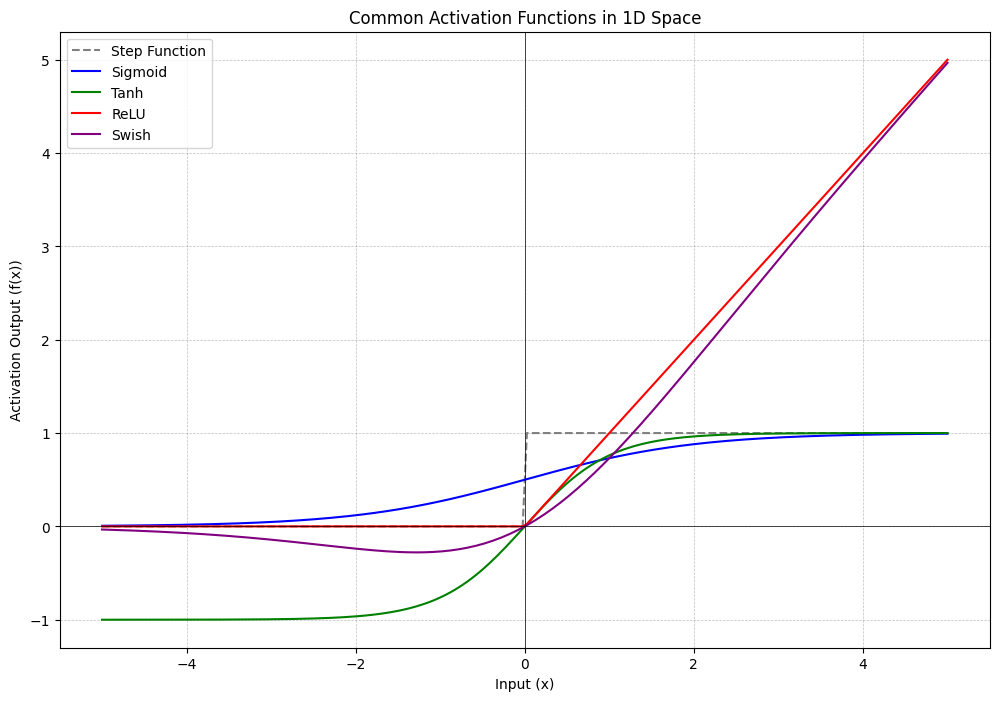

In [2]:
def plot_activation_functions():
    x = np.linspace(-5, 5, 200)

    # Funções de ativação simples
    step = np.where(x >= 0, 1, 0)
    sigmoid = 1 / (1 + np.exp(-x))
    tanh = np.tanh(x)
    relu = np.maximum(0, x)
    swish = x * sigmoid

    plt.figure(figsize=(12, 8))

    # Plotagem
    plt.plot(x, step, label='Step Function', linestyle='--', color='gray')
    plt.plot(x, sigmoid, label='Sigmoid', color='blue')
    plt.plot(x, tanh, label='Tanh', color='green')
    plt.plot(x, relu, label='ReLU', color='red')
    plt.plot(x, swish, label='Swish', color='purple')

    # Configurações do gráfico padrão científico
    plt.title('Common Activation Functions in 1D Space')
    plt.xlabel('Input (x)')
    plt.ylabel('Activation Output (f(x))')
    plt.axhline(0, color='black', linewidth=0.5)
    plt.axvline(0, color='black', linewidth=0.5)
    plt.grid(color='gray', linestyle='--', linewidth=0.5, alpha=0.5)
    plt.legend(loc='upper left')
    plt.show()

plot_activation_functions()

### 3. Teoria formal

Esta seção detalha a formulação matemática rigorosa das principais funções de ativação, o que é crítico para entender o fluxo de gradientes durante o treinamento.

O treinamento de redes neurais profundas via *backpropagation* requer que as funções de ativação sejam diferenciáveis na maior parte de seus pontos, possibilitando a aplicação da regra da cadeia.

**Sigmoid**
A função Sigmoid mapeia qualquer entrada para um intervalo contínuo entre $(0, 1)$, introduzindo uma noção de probabilidade.
$$f(x) = \frac{1}{1 + e^{-x}}$$
Sua derivada é expressa de forma eficiente em termos da própria função: $f'(x) = f(x)(1 - f(x))$.
*Limitação:* Sofre do problema de dissipação de gradiente (*vanishing gradient*), onde entradas com valores absolutos muito grandes produzem gradientes muito próximos de zero, travando o aprendizado.

**Tangente Hiperbólica (Tanh)**
A Tanh mapeia valores para o intervalo $(-1, 1)$, mantendo a saída centrada em zero, o que ajuda na estabilidade da otimização.
$$f(x) = \frac{e^x - e^{-x}}{e^x + e^{-x}}$$
A derivada é $f'(x) = 1 - f(x)^2$. *Hipótese:* Permite propagar valores negativos, reduzindo levemente o *vanishing gradient* em relação à Sigmoid, mas ainda sofre saturação nas extremidades.

**Rectified Linear Unit (ReLU)**
A função ReLU define a saída como zero para valores negativos e preserva a magnitude para valores positivos.
$$f(x) = \max(0, x)$$
*Motivação:* A derivada de $f(x)$ para $x > 0$ é estritamente 1, o que resolve o *vanishing gradient* para a região positiva do domínio e é computacionalmente extremamente eficiente.
*Limitação:* Introduz o problema de neurônios mortos, onde saídas consistentemente negativas geram gradientes zero, inativando partes da rede permanentemente.

**Swish e SwiGLU**
Introduzida pela Google DeepMind, a Swish é uma função suave e não monotônica.
$$Swish(x) = x \cdot \sigma(x)$$
A SwiGLU estende essa formulação utilizando o mecanismo de *Gated Linear Unit* (GLU).
$$SwiGLU(x) = Swish(xW_1) \odot (xW_2)$$
*Interpretação:* Funciona como um filtro adaptativo que não satura e suaviza o cenário de aprendizado, mitigando os problemas observados nas funções anteriores à custa de maior processamento computacional.

### 4. Algoritmos

Esta seção traduz a teoria formal em pseudocódigo algorítmico, o que é necessário para a correta implementação computacional dos modelos.

O cálculo das funções de ativação modernas, especialmente mecanismos baseados em portas (*gates*) como a SwiGLU, envolve um grafo computacional de operações específicas. Abaixo está o pseudocódigo para a ativação de uma camada linear através do SwiGLU.

```text
Algoritmo: Ativação SwiGLU (Forward Pass)
Entrada: Vetor de características x, Matriz de pesos W1, Matriz de pesos W2
Saída: Vetor ativado f(x)

1. Calcular a projeção linear do primeiro caminho:
   A = multiplicar matrizes(x, W1)
2. Calcular a projeção linear do segundo caminho (Gate):
   B = multiplicar matrizes(x, W2)
3. Aplicar a função Swish na primeira projeção:
   A_swish = A * (1 / (1 + exponencial(-A)))
4. Combinar caminhos usando a operação Hadamard (multiplicação elemento a elemento):
   Resultado = A_swish * B
5. Retornar Resultado
```

### 5. Implementação from scratch

Esta seção implementa as funções de ativação puramente em Python e NumPy, o que revela os mecanismos subjacentes sem a abstração de frameworks de alto nível.

O código implementa versões vetorizadas (para eficiência computacional) das funções e de suas respectivas derivadas.

In [3]:
def sigmoid(x: np.ndarray) -> np.ndarray:
    """
    Computes the Sigmoid activation function.
    Clips values to avoid floating point overflow in np.exp.
    """
    x_clipped = np.clip(x, -500, 500)
    return 1.0 / (1.0 + np.exp(-x_clipped))

def sigmoid_derivative(x: np.ndarray) -> np.ndarray:
    """
    Computes the derivative of the Sigmoid function.
    """
    sig = sigmoid(x)
    return sig * (1.0 - sig)

def relu(x: np.ndarray) -> np.ndarray:
    """
    Computes the Rectified Linear Unit (ReLU) activation function.
    """
    return np.maximum(0.0, x)

def relu_derivative(x: np.ndarray) -> np.ndarray:
    """
    Computes the derivative of the ReLU function.
    The derivative is exactly 1 where x > 0, and 0 otherwise.
    """
    return np.where(x > 0, 1.0, 0.0)

def swish(x: np.ndarray) -> np.ndarray:
    """
    Computes the Swish activation function proposed by Google DeepMind.
    f(x) = x * sigmoid(x)
    """
    return x * sigmoid(x)

# Asserts para validação da implementação base
x_test = np.array([-1.0, 0.0, 1.0])

# Validação do Sigmoid e suas derivadas
assert np.allclose(sigmoid(np.array([0.0])), [0.5]), "Erro na Sigmoid: F(0) deve ser 0.5"
assert np.allclose(relu(x_test), [0.0, 0.0, 1.0]), "Erro na ReLU"
assert np.allclose(relu_derivative(x_test), [0.0, 0.0, 1.0]), "Erro na Derivada ReLU"

print("Todas as implementações base NumPy validadas com sucesso!")

Todas as implementações base NumPy validadas com sucesso!


### 6. Implementação em PyTorch

Esta seção recria as implementações utilizando o ecossistema do PyTorch, o que aproxima o código de cenários práticos de produção em aprendizado profundo.

O PyTorch cuida do *backward pass* automaticamente através de seu módulo de diferenciação `autograd`. A API fornece funções nativas em `torch.nn.functional` para extrema eficiência através da paralelização em tensores e, em cenários reais, execução em GPUs.

In [4]:
# Criação do tensor de entrada requerendo o rastreio do gradiente
x_torch = torch.tensor([-2.0, 0.0, 2.0], requires_grad=True)

# Aplicação das funções via PyTorch puro
sigmoid_out = torch.sigmoid(x_torch)
relu_out = F.relu(x_torch)
swish_out = F.silu(x_torch)  # Em PyTorch, Swish é tipicamente implementado como SiLU

# Validação visual de que a saída do PyTorch é matematicamente equivalente à NumPy
assert np.allclose(swish_out.detach().numpy(), swish(x_torch.detach().numpy())), "Inconsistência na função Swish"

# Simulando um cálculo de erro (Loss fictícia = soma das ativações)
loss = swish_out.sum()

# Backward pass automático do PyTorch para cálculo das derivadas
loss.backward()

print('Tensores de Entrada:', x_torch)
print('Saída Swish PyTorch:', swish_out)
print('Gradientes (Derivada local) computados automaticamente:', x_torch.grad)

Tensores de Entrada: tensor([-2.,  0.,  2.], requires_grad=True)
Saída Swish PyTorch: tensor([-0.2384,  0.0000,  1.7616], grad_fn=<SiluBackward0>)
Gradientes (Derivada local) computados automaticamente: tensor([-0.0908,  0.5000,  1.0908])


### 7. Experimentos e análise

Esta seção executa experimentos comparativos controlados entre diferentes funções de ativação, o que demonstra empiricamente o problema de dissipação de gradientes e a velocidade de convergência.

O experimento a seguir treina um *Multi Layer Perceptron* (MLP) simples em um conjunto de dados 2D utilizando duas topologias idênticas em hiperparâmetros, exceto pela função de ativação das camadas ocultas. O gráfico monitora as curvas de perda (*loss*) correspondentes. Note que o monitoramento indica eventuais instabilidades ou incapacidade de redução da perda. A persistência de um erro alto frequentemente acusa um diagnóstico de ativações saturadas ou hiperparâmetros (como a taxa de aprendizado) inadequados.

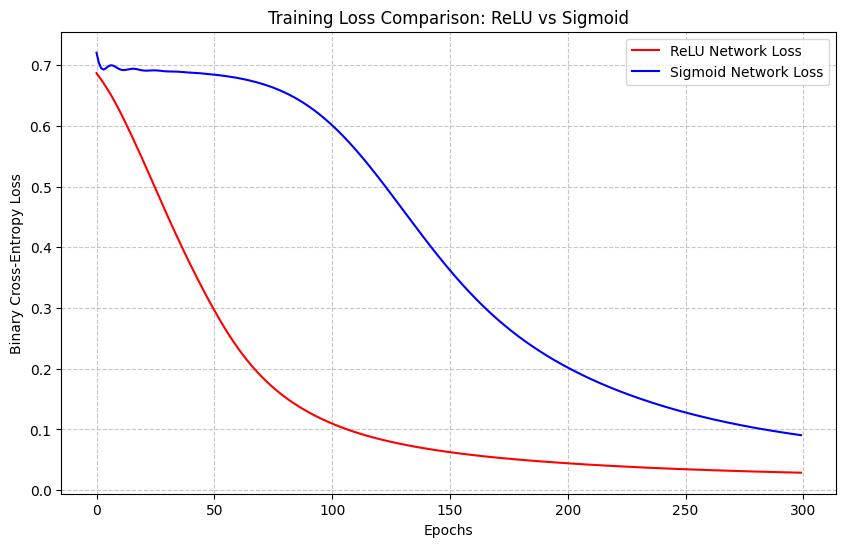

In [5]:
from sklearn.datasets import make_circles

# Geração de dataset não linear toy (Círculos concêntricos)
X_data, y_data = make_circles(n_samples=500, noise=0.1, factor=0.5, random_state=42)
X_tensor = torch.FloatTensor(X_data)
y_tensor = torch.FloatTensor(y_data).unsqueeze(1)

class SimpleMLP(nn.Module):
    def __init__(self, activation_name='relu'):
        super().__init__()
        self.fc1 = nn.Linear(2, 32)
        self.fc2 = nn.Linear(32, 1)
        self.activation_name = activation_name

    def forward(self, x):
        x = self.fc1(x)
        if self.activation_name == 'sigmoid':
            x = torch.sigmoid(x)
        elif self.activation_name == 'relu':
            x = F.relu(x)
        return torch.sigmoid(self.fc2(x))

def train_model(activation_name, epochs=300):
    model = SimpleMLP(activation_name)
    optimizer = torch.optim.Adam(model.parameters(), lr=0.01)
    criterion = nn.BCELoss()

    losses = []
    for epoch in range(epochs):
        optimizer.zero_grad()
        predictions = model(X_tensor)
        loss = criterion(predictions, y_tensor)
        loss.backward()
        optimizer.step()
        losses.append(loss.item())
    return losses

loss_relu = train_model('relu')
loss_sigmoid = train_model('sigmoid')

# Geração do gráfico comparativo
plt.figure(figsize=(10, 6))
plt.plot(loss_relu, label='ReLU Network Loss', color='red')
plt.plot(loss_sigmoid, label='Sigmoid Network Loss', color='blue')
plt.title('Training Loss Comparison: ReLU vs Sigmoid')
plt.xlabel('Epochs')
plt.ylabel('Binary Cross-Entropy Loss')
plt.legend(loc='best')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

### 8. Conexões com ML moderno

Esta seção conecta os conceitos fundamentais aos modelos de estado da arte contemporâneos, o que responde por que esses elementos continuam sendo o cerne da inteligência artificial moderna.

A evolução na arquitetura de modelos massivos na era de 2024-2025 mostra que as funções de ativação desempenham papel preponderante no sucesso do escalonamento de redes neurais. Enquanto a função ReLU dominou o ecossistema desde 2012 (como no AlexNet), a transição para Grandes Modelos de Linguagem (*LLMs*) estabeleceu novas convenções. Modelos da família LLaMa (Meta) e Mistral utilizam exclusivamente funções baseadas em portas (*gates*), primariamente a SwiGLU.

* *Ramachandran et al. (2017) - Searching for Activation Functions:* Introduz empiricamente a função Swish e prova melhorias de convergência consistentes quando aplicadas em redes muito profundas no lugar da ReLU.
* *Shazeer (2020) - GLU Variants Improve Transformer:* Demonstra experimentalmente que substituições da camada MLP padrão dos Transformers por variações da *Gated Linear Unit*, como a SwiGLU, trazem ganhos significativos de desempenho no pré-treinamento de linguagem, independentemente de restrições em hiperparâmetros.

O papel desses mecanismos de ativação hoje se concentra em balancear expressividade, gradientes ininterruptos e maximização do uso dos registradores otimizados do hardware paralelizado.

### 9. Exercícios

Esta seção propõe exercícios resolvidos e desafios abertos, o que consolida o aprendizado através da resolução ativa de problemas inspirados no documento oficial da aula.

#### Exercícios Resolvidos

**1. Por que a função degrau não é adequada para aprendizado via backpropagation?**
A função degrau (step function) não permite que informações de gradientes sejam propagadas em uma rede neural profunda de forma contínua. A sua derivada é zero em quase todos os pontos (e indefinida na mudança do degrau), o que congela a atualização dos pesos baseada na regra da cadeia contínua requerida pelo algoritmo do gradiente descendente.

**2. Escreva a fórmula da função Sigmoid e demonstre a sua derivada em função dela mesma.**
A fórmula é $f(x) = \frac{1}{1 + e^{-x}}$.
Para a derivada matemática via regra do quociente em relação a $x$:
$$f'(x) = \frac{e^{-x}}{(1 + e^{-x})^2}$$
Essa fração pode ser reescrita da seguinte maneira adicionando +1-1 no numerador:
$$f'(x) = \frac{1}{(1 + e^{-x})} \cdot \frac{(1 + e^{-x} - 1)}{(1 + e^{-x})}$$
$$f'(x) = f(x) \cdot (1 - f(x))$$
Esta formulação simplifica a computação na etapa *backward*, reciclando as variáveis ativadas do *forward pass*.

**3. Qual é o problema conhecido como neurônios mortos associado à ReLU e como a Leaky ReLU o resolve?**
A função ReLU mapeia qualquer entrada negativa para 0. Se a ativação inicial (combinada com viés negativo grande) cair nessa zona, a derivada local será exatamente 0. Durante a aplicação iterativa do *backpropagation*, o peso jamais será atualizado pois a multiplicação em cadeia será anulada. A Leaky ReLU soluciona o problema redefinindo a função para $f(x) = \max(\alpha x, x)$, onde $\alpha$ é um valor pequeno (ex: 0.01). Assim, quando $x < 0$, existe um gradiente não nulo constante igual a $\alpha$, evitando o congelamento dos pesos.

#### Desafios Abertos

**Desafio 1 (Sem solução): Estabilidade Numérica na Função Softmax**
A formulação clássica da Softmax exige computar $e^x$, o que frequentemente causa transbordamento numérico (*overflow*) de *floating points* em implementações brutas. Modifique a função computacional para usar o truque do deslocamento (*Shift Invariant*) subtraindo o valor máximo do vetor $x$ de todos os elementos antes da exponencial. Prove através de implementação iterativa que o resultado mantém a soma do vetor 1.0 e discuta por que os resultados matemáticos permanecem os mesmos.

**Desafio 2 (Sem solução): Derivação Manual da Função Swish**
Baseando-se na regra do produto da derivação $(u \cdot v)' = u'v + uv'$, derive analiticamente a equação diferencial da função de ativação Swish: $f(x) = x \cdot \sigma(x)$. Observe a relação algébrica em que a derivada forma $f'(x) = \sigma(x) + f(x) \cdot (1 - \sigma(x))$. Programe uma célula e demonstre essa equivalência plottando a derivada contra a função original usando matplotlib.